# EXAMEN FINAL — Análisis de Emisiones de CO2
**Curso:** Fundamentos de Python  
**Universidad:** UMCA  
**Docente:** Ing. Andrés Mena Abarca

**Estudiante:** <mark>Odel Leal Hernández</mark>

## Archivo de trabajo
`Estimaciones_Emisiones_Dioxido_Carbono.csv`

## Propósito
Este examen final integra los contenidos principales del curso: carga y exploración de datos, uso de listas, diccionarios, ciclos, funciones, análisis con `pandas`, visualización con `matplotlib` y comunicación de hallazgos con evidencia.


## Idea central del caso
El dataset contiene emisiones de CO2 de varios países entre 1975 y 2017. Cada fila representa una observación para un país, un año y un tipo de medición.

Hay **dos tipos de emisión**:
- `Emisiones (kilotoneladas metricas de dioxido de carbono)`
- `Emisiones per capita (toneladas metricas de dioxido de carbono)`

### Atención
Estas dos métricas **no significan lo mismo**. Parte del examen consiste en distinguirlas correctamente y evitar comparaciones equivocadas.


## Entregables esperados
1. Código funcional y ordenado.
2. Evidencia de comprensión del dataset.
3. Uso de **4 funciones obligatorias** creadas por ti.
4. Resolución de un bloque con Python base.
5. Resolución de un bloque con `pandas`.
6. Dos gráficos correctamente rotulados.
7. Un informe final crítico con evidencia numérica.


## Distribución de puntaje (100 puntos)
- **Bloque 1 — Comprensión del dataset:** 10 pts
- **Bloque 2 — Normalización y preparación analítica:** 10 pts
- **Bloque 3 — Resolución con Python base:** 22 pts
- **Bloque 4 — Análisis con pandas:** 28 pts
- **Bloque 5 — Visualización con matplotlib:** 10 pts
- **Bloque 6 — Informe final crítico:** 20 pts


## Rúbrica por niveles de desempeño

### Niveles
- **No logrado:** no cumple el objetivo central del bloque o presenta errores conceptuales clave.
- **Inicial:** hay intento válido, pero faltan componentes esenciales o hay confusiones importantes.
- **Intermedio:** resuelve correctamente la mayor parte, con interpretación suficiente.
- **Logrado:** resuelve con precisión, explica bien y conecta el resultado con el análisis.

### Criterio general
El examen no se califica solo por obtener un número correcto. También se valora el razonamiento, el uso adecuado de la herramienta y la capacidad de interpretar.


In [39]:
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import pandas as pd

ARCHIVO = "Estimaciones_Emisiones_Dioxido_Carbono.csv"


---
## Bloque 1 — Comprensión del dataset (10 pts)

### Objetivo
Comprender la estructura real del archivo antes de empezar a analizar.

### Debes hacer exactamente esto
1. Cargar el CSV en un DataFrame llamado `df_raw`.
2. Mostrar:
   - `df_raw.shape`
   - lista de columnas
   - `df_raw.head(5)`
   - años disponibles
   - tipos de emisión disponibles
   - cantidad de países únicos
3. Escribir un texto breve de **4 a 6 líneas** respondiendo:
   - qué representa una fila del dataset,
   - qué diferencia conceptual existe entre `emisiones_totales` y `emisiones_per_capita`,
   - por qué sería incorrecto compararlas como si fueran exactamente lo mismo.

### Nivel esperado
- **No logrado:** carga incompleta o confusión sobre la estructura del archivo.
- **Inicial:** identifica elementos básicos, pero no explica bien la diferencia entre métricas.
- **Intermedio:** describe correctamente la estructura y distingue ambas métricas.
- **Logrado:** además de distinguirlas, explica por qué esa diferencia afecta el análisis.


In [40]:
import pandas as pd

# 1.1 Cargar el CSV en un DataFrame llamado df_raw
ARCHIVO = "Estimaciones_Emisiones_Dioxido_Carbono.csv"
df_raw = pd.read_csv(ARCHIVO, encoding='utf-8') 



In [41]:
# 1.2 Muestra shape, columnas, head(5), años disponibles, tipos de emisión y países únicos

# df_raw.shape
print("👇 --- Forma del dataset (filas, columnas) ---")
print(df_raw.shape)

# lista de columnas
print("\n👇 --- Lista de columnas ---")
print(df_raw.columns.tolist())

# df_raw.head(5)
print("\n👇 --- Primeras 5 filas ---")
print(df_raw.head())

# Años disponibles
print("\n👇 --- Años disponibles ---")
anios = df_raw['Year'].unique()
anios.sort()
print(anios)

# tipos de emisión disponibles 
print("\n👇 --- Tipos de emisión disponibles ---")
tipos_emision = df_raw['Type'].unique()
print(tipos_emision)

# cantidad de países únicos
print("\n👇 --- Cantidad de países únicos ---")
cantidad_paises = df_raw['Country'].nunique()
print(cantidad_paises)

👇 --- Forma del dataset (filas, columnas) ---
(2132, 4)

👇 --- Lista de columnas ---
['Country', 'Year', 'Type', 'Value']

👇 --- Primeras 5 filas ---
   Country  Year                                               Type     Value
0  Albania  1975  Emisiones (kilotoneladas metricas de dioxido d...  4338.334
1  Albania  1985  Emisiones (kilotoneladas metricas de dioxido d...  6929.926
2  Albania  1995  Emisiones (kilotoneladas metricas de dioxido d...  1848.549
3  Albania  2005  Emisiones (kilotoneladas metricas de dioxido d...  3825.184
4  Albania  2010  Emisiones (kilotoneladas metricas de dioxido d...  3930.295

👇 --- Años disponibles ---
[1975 1985 1995 2005 2010 2015 2016 2017]

👇 --- Tipos de emisión disponibles ---
['Emisiones (kilotoneladas metricas de dioxido de carbono)'
 'Emisiones per capita (toneladas metricas de dioxido de carbono)']

👇 --- Cantidad de países únicos ---
142


### <mark>Explicación conceptual del Bloque 1</mark>
Una fila de la base de datos representa el registro de un tipo específico de emisión de CO2 para un país determinado en un año concreto. La diferencia principal es que las emisiones totales miden la cantidad absoluta de dióxido de carbono que genera un país entero (impacto global), mientras que las emisiones per cápita dividen ese total entre el número de habitantes (impacto promedio por persona). 
Sería incorrecto compararlas como si fueran lo mismo porque un país muy poblado puede tener emisiones totales gigantescas, pero emisiones per cápita bajas porque el dato se diluye entre el montón de personas, mientras que un país pequeño muy industrializado podría tener el caso inverso; mezclarlas llevaría a conclusiones equivocadas sobre el nivel de contaminación.

---
## Bloque 2 — Normalización y preparación analítica (10 pts)

### Objetivo
Transformar la estructura del dataset a una forma más legible para el análisis, sin alterar el contenido original de los datos.

### Nombres obligatorios
Debes crear:
- `df_trabajo`
- `df_totales_es`
- `df_per_capita_es`
- función `renombrar_columnas_es(df)`
- función `separar_por_tipo(df, tipo_emision)`

### Requisitos exactos
1. Crear una función `renombrar_columnas_es(df)` que retorne una copia del DataFrame con estas columnas:
   - `pais`
   - `anio`
   - `tipo_emision`
   - `valor`
2. Aplicar esa función y guardar el resultado en `df_trabajo`.
3. Crear una función `separar_por_tipo(df, tipo_emision)` que filtre un DataFrame según el valor exacto de `tipo_emision`.
4. Crear:
   - `df_totales_es`
   - `df_per_capita_es`
5. Mostrar evidencia de que la preparación fue correcta:
   - columnas de `df_trabajo`
   - primeras 5 filas de `df_trabajo`
   - shape de `df_totales_es`
   - shape de `df_per_capita_es`
6. Escribir una reflexión breve de **2 a 3 líneas** respondiendo:
   - por qué renombrar columnas al español puede ayudar al análisis,
   - por qué separar emisiones totales y per cápita es necesario antes de comparar.

### Nota pedagógica
En este bloque no se espera corregir errores del archivo, porque el dataset original ya es consistente. Se espera que prepares una versión más clara para trabajar y que evites mezclar métricas distintas.

### Nivel esperado
- **No logrado:** no renombra correctamente las columnas o no separa bien los dos tipos de emisión.
- **Inicial:** renombra parcialmente o separa con errores menores, pero la intención del proceso es visible.
- **Intermedio:** renombra correctamente, separa bien ambos subconjuntos y muestra evidencia básica de que el trabajo quedó listo para analizar.
- **Logrado:** además de lo anterior, explica con claridad por qué la normalización semántica y la separación por métrica mejoran la lectura y reducen errores analíticos.


In [42]:
# Nombre de las columnas en una lista.
nuevo_nombre_cols = ["pais","anio", "tipo_emision" ,"valor"]

# 2.1. Función renombrado de columnas
def renombrar_columnas_es(df):
    """Función para renombrar las columnas. Recibe una lista """
    # se crea la copia para no modificar el DataFrame original
    df_copia = df.copy()
    # Asignamos los nuevos nombres de columnas
    df_copia.columns = nuevo_nombre_cols
    return df_copia


# 2.2 Aplico la función y genero el nuevo df_trabajo
df_trabajo = renombrar_columnas_es(df_raw)

# 2.3 Definición de la función para separar por tipo 
def separar_por_tipo(df, tipo_emision):
    """Función para separar los tipos de emisión"""
    # Filtro el tipo de 
    df_filtrado = df[df['tipo_emision'] == tipo_emision]
    return df_filtrado

# 2.4 Creación de los DataFrames específicos
# Usamos los nombres exactos del dataset original para filtrar
TIPO_TOTAL = "Emisiones (kilotoneladas metricas de dioxido de carbono)"
TIPO_PER_CAPITA = "Emisiones per capita (toneladas metricas de dioxido de carbono)"

# aplicación de la función 'separar_por_tipo'
df_totales_es = separar_por_tipo(df_trabajo, TIPO_TOTAL)
df_per_capita_es = separar_por_tipo(df_trabajo, TIPO_PER_CAPITA)







In [43]:
# 2.5 Evidencia de la preparación
print("👇 --- Columnas renombradas en españo de df_trabajo ---")
print(df_trabajo.columns.tolist())

print("\n👇 --- Primeras 5 filas de df_trabajo ---")
print(df_trabajo.head(5))

print("\n👇 --- Shape de df_totales_es ---")
print(df_totales_es.shape)

print("\n 👇--- Shape de df_per_capita_es ---")
print(df_per_capita_es.shape)


👇 --- Columnas renombradas en españo de df_trabajo ---
['pais', 'anio', 'tipo_emision', 'valor']

👇 --- Primeras 5 filas de df_trabajo ---
      pais  anio                                       tipo_emision     valor
0  Albania  1975  Emisiones (kilotoneladas metricas de dioxido d...  4338.334
1  Albania  1985  Emisiones (kilotoneladas metricas de dioxido d...  6929.926
2  Albania  1995  Emisiones (kilotoneladas metricas de dioxido d...  1848.549
3  Albania  2005  Emisiones (kilotoneladas metricas de dioxido d...  3825.184
4  Albania  2010  Emisiones (kilotoneladas metricas de dioxido d...  3930.295

👇 --- Shape de df_totales_es ---
(1066, 4)

 👇--- Shape de df_per_capita_es ---
(1066, 4)


### <mark>Reflexión corta del Bloque 2</mark>
Renombrar las columnas al español facilita la escritura del código y reduce errores de dedo al llamar variables. Además, separar los tipos de emisión es fundamental porque son unidades de medida distintas (kilotoneladas vs. toneladas por persona), y mezclarlas en un mismo análisis o gráfico daría resultados numéricos sin sentido lógico, como se dice popularmente: <mark>_'Mezclar papas con chayotes"_</mark>.


---
## Bloque 3 — Resolución con Python base (22 pts)

### Objetivo
Resolver parte del análisis usando listas, diccionarios, ciclos, condicionales y funciones, sin depender de agregaciones de `pandas`.

### Regla del bloque
En este bloque **no uses** `groupby` ni agregaciones avanzadas de `pandas` para obtener las respuestas principales.

### Nombres obligatorios
Debes crear:
- `registros_totales`
- función `resumen_pais(registros, pais)`
- `prediccion_inicial`
- `paises_ordenados`
- `valor_maximo_total`
- `pais_valor_maximo_total`
- `anio_max_costa_rica`
- `reporte_centroamerica_base`

### Activación de hipótesis
Antes de calcular, escribe en `prediccion_inicial` una oración corta respondiendo:
“¿Qué país crees que tendrá el mayor valor registrado en emisiones totales y por qué?”

### La función `resumen_pais(registros, pais)` debe retornar un diccionario con estas claves exactas
- `pais`
- `cantidad_registros`
- `anio_min`
- `anio_max`
- `valor_max`

### Resuelve exactamente estas tareas con Python base
1. Convertir `df_totales_es` en una lista de diccionarios llamada `registros_totales`.
2. Obtener una lista alfabética de países únicos y guardarla en `paises_ordenados`.
3. Obtener el valor máximo global de emisiones totales y guardarlo en `valor_maximo_total`.
4. Obtener el país asociado a ese valor y guardarlo en `pais_valor_maximo_total`.
5. Obtener el año en que Costa Rica alcanza su mayor emisión total y guardarlo en `anio_max_costa_rica`.
6. Construir `reporte_centroamerica_base` para estos países:
   - `Costa Rica`
   - `Guatemala`
   - `Honduras`
   - `El Salvador`
   - `Nicaragua`

El formato esperado de `reporte_centroamerica_base` es una **lista de diccionarios** con estas claves exactas:
- `anio`
- `total_por_anio`

### Cierre del bloque
Escribe **2 a 3 líneas** comparando tu predicción inicial con la evidencia obtenida.

### Nivel esperado
- **No logrado:** no resuelve la lógica esencial o depende indebidamente de `pandas`.
- **Inicial:** resuelve fragmentos, pero con errores en acumulación, filtrado o estructura.
- **Intermedio:** responde correctamente la mayoría de tareas y construye el reporte base.
- **Logrado:** domina la lógica base y contrasta su intuición con la evidencia de forma clara.


In [44]:
# 3.1 Escribe aquí tu prediccion_inicial y luego crea registros_totales a partir de df_totales_es
prediccion_inicial = "Creo que Estados Unidos o China tendrán el mayor valor registrado en emisiones totales, debido a que son potencias mundiales altamente industrializadas y con poblaciones inmensas."
print(f"Predicción inicial: {prediccion_inicial}\n")

registros_totales = df_totales_es.to_dict('records')
print(registros_totales)

Predicción inicial: Creo que Estados Unidos o China tendrán el mayor valor registrado en emisiones totales, debido a que son potencias mundiales altamente industrializadas y con poblaciones inmensas.

[{'pais': 'Albania', 'anio': 1975, 'tipo_emision': 'Emisiones (kilotoneladas metricas de dioxido de carbono)', 'valor': 4338.334}, {'pais': 'Albania', 'anio': 1985, 'tipo_emision': 'Emisiones (kilotoneladas metricas de dioxido de carbono)', 'valor': 6929.926}, {'pais': 'Albania', 'anio': 1995, 'tipo_emision': 'Emisiones (kilotoneladas metricas de dioxido de carbono)', 'valor': 1848.549}, {'pais': 'Albania', 'anio': 2005, 'tipo_emision': 'Emisiones (kilotoneladas metricas de dioxido de carbono)', 'valor': 3825.184}, {'pais': 'Albania', 'anio': 2010, 'tipo_emision': 'Emisiones (kilotoneladas metricas de dioxido de carbono)', 'valor': 3930.295}, {'pais': 'Albania', 'anio': 2015, 'tipo_emision': 'Emisiones (kilotoneladas metricas de dioxido de carbono)', 'valor': 3824.801}, {'pais': 'Albania'

In [45]:
# 3.2 Crea aquí la función resumen_pais(registros, pais)
def resumen_pais(registros, pais):
    """Función Resumen país"""
    cantidad = 0
    # Inicializamos con valores extremos para poder comparar
    anio_min = float('inf') 
    anio_max = 0
    valor_max = 0.0
    
    for registro in registros:
        if registro['pais'] == pais:
            cantidad += 1
            if registro['anio'] < anio_min:
                anio_min = registro['anio']
            if registro['anio'] > anio_max:
                anio_max = registro['anio']
            # Verificamos que el valor no sea None y sea un número válido (sin pandas)
            valor = registro['valor']
            if valor is not None and isinstance(valor, (int, float)) and valor > valor_max:
                valor_max = valor
                
    return {
        'pais': pais,
        'cantidad_registros': cantidad,
        'anio_min': anio_min if cantidad > 0 else None,
        'anio_max': anio_max if cantidad > 0 else None,
        'valor_max': valor_max
    }

# Prueba rápida de la función resumen_pais con Costa Rica por ejemplo
resumen_costa_rica = resumen_pais(registros_totales, 'Costa Rica')
print("\n👇--- Prueba de la función resumen_pais ---")
print(resumen_costa_rica)


# 2. Obtener lista alfabética de países únicos
paises_set = set()
for registro in registros_totales:
    paises_set.add(registro['pais'])

paises_ordenados = sorted(list(paises_set))
print("\n 👇 --- Se han ordenado alfabéticamente los países ---")
print(paises_ordenados)

# 3 y 4. Obtener el valor máximo global y el país asociado
valor_maximo_total = 0.0
pais_valor_maximo_total = ""

for reg in registros_totales:
    if pd.notna(reg['valor']) and reg['valor'] > valor_maximo_total:
        valor_maximo_total = reg['valor']
        pais_valor_maximo_total = reg['pais']

print(f"\n 👇 ---- País con mayor emisión histórica: \n     {pais_valor_maximo_total} ({valor_maximo_total:,.2f} kt)")

# 5. Obtener el año en que Costa Rica alcanza su mayor emisión total
max_cr = 0.0
anio_max_costa_rica = 0

for reg in registros_totales:
    if reg['pais'] == 'Costa Rica':
        if pd.notna(reg['valor']) and reg['valor'] > max_cr:
            max_cr = reg['valor']
            anio_max_costa_rica = reg['anio']

porcentaje_cr = (max_cr / valor_maximo_total) * 100 if valor_maximo_total > 0 else 0

print(f"\n 👇 ---- Año de mayor emisión en Costa Rica: \n    🟦⬜🟥⬜🟦 {anio_max_costa_rica} con un total de {max_cr:,.2f} kt ({porcentaje_cr:.2f}%)")
print(f"ℹ️ Lo que demuestra que Costa Rica, aunque ha tenido un crecimiento en sus emisiones, representa una fracción muy pequeña del total global, \n lo que resalta su compromiso con la sostenibilidad y la conservación ambiental en comparación con países más industrializados.")


👇--- Prueba de la función resumen_pais ---
{'pais': 'Costa Rica', 'cantidad_registros': 8, 'anio_min': 1975, 'anio_max': 2017, 'valor_max': 7584.411}

 👇 --- Se han ordenado alfabéticamente los países ---
['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Benin', 'Bolivia (Plurin. State of)', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Cambodia', 'Cameroon', 'Canada', 'Chile', 'China', 'China Hong Kong SAR', 'Colombia', 'Congo', 'Costa Rica', 'Croatia', 'Cuba', 'Curaçao', 'Cyprus', 'Czechia', 'Côte d’Ivoire', "Dem. People's Rep. Korea", 'Dem. Rep. of the Congo', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Eritrea', 'Estonia', 'Ethiopia', 'Finland', 'France', 'Gabon', 'Georgia', 'Germany', 'Ghana', 'Gibraltar', 'Greece', 'Guatemala', 'Haiti', 'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran (Islamic Republic of)', 'Iraq'

In [46]:
# 6. Reporte Centromérica base
paises_ca = ['Costa Rica', 'Guatemala', 'Honduras', 'El Salvador', 'Nicaragua']
agrupacion_anios = {} 

for reg in registros_totales:
    if reg['pais'] in paises_ca:
        anio = reg['anio']
        valor = reg['valor'] if pd.notna(reg['valor']) else 0.0
        
        # Si el año no existe en el diccionario, lo creamos
        if anio not in agrupacion_anios:
            agrupacion_anios[anio] = 0.0
        
        # Acumulamos el valor
        agrupacion_anios[anio] += valor

# Convertimos el diccionario en la lista de diccionarios, ordenando por año
reporte_centroamerica_base = []
for anio in sorted(agrupacion_anios.keys()):
    reporte_centroamerica_base.append({
        'anio': anio,
        'total_por_anio': agrupacion_anios[anio]
    })

print("\n 👇--- Primeros 3 registros del reporte Centroamérica ---")
print(reporte_centroamerica_base[:3])



 👇--- Primeros 3 registros del reporte Centroamérica ---
[{'anio': 1975, 'total_por_anio': 9860.972}, {'anio': 1985, 'total_por_anio': 10250.333}, {'anio': 1995, 'total_por_anio': 20960.233999999997}]


### <mark>Reflexión corta del Bloque 3</mark>
Mi predicción inicial era muy certera desde la lógica económica, asumiendo que potencias como EE.UU. o China tendrían el récord. Esto demuestra que con altos niveles de población e industrialización presenta mayores volúmenes de contaminación a nivel mundial. 

Además, demuestra que Costa Rica, aunque ha tenido un crecimiento en sus emisiones, representa una fracción muy pequeña del total global, lo que resalta su compromiso con la sostenibilidad y la conservación ambiental en comparación con países más industrializados.


---
## Bloque 4 — Análisis con pandas (28 pts)

### Objetivo
Resolver el análisis con herramientas tabulares más compactas usando `pandas`, distinguiendo claramente entre emisiones totales y per cápita.

### Nombres obligatorios
Debes crear:
- `reporte_total_centroamerica`
- `reporte_promedio_centroamerica`
- `conversiones_costa_rica`
- función `comparar_paises(df, paises)`
- `contraste_metricas`

### Requisitos exactos
1. Usando `df_totales_es`, responder:
   - cuántos países únicos hay,
   - cuál es el valor máximo global,
   - cuál es el país con ese valor máximo.
2. Usando `df_per_capita_es`, calcular el promedio de emisiones per cápita para el año `2005`.
3. Construir `reporte_total_centroamerica` con columnas exactas:
   - `anio`
   - `total_por_anio`
4. Construir `reporte_promedio_centroamerica` con columnas exactas:
   - `anio`
   - `promedio_por_anio`
5. Construir `conversiones_costa_rica` con columnas exactas:
   - `anio`
   - `valor`
   - `kilogramos`
   - `libras`
6. Crear la función `comparar_paises(df, paises)` para devolver un DataFrame filtrado y listo para comparar esos países dentro de una misma métrica.
   Luego úsala para construir una salida visible llamada `comparacion_2017`, filtrando el año `2017` para estos países: `Costa Rica`, `Guatemala`, `Honduras`, `El Salvador`, `Nicaragua` y `Spain`.
   Muestra únicamente las columnas `pais`, `anio` y `valor`, ordenadas de mayor a menor por `valor`.
7. Crear `contraste_metricas` como un texto corto de **4 a 5 líneas** respondiendo esta idea:
   - por qué un país puede tener emisiones totales altas y no necesariamente emisiones per cápita altas.
   Debes apoyar tu respuesta con al menos **1 ejemplo concreto del dataset**.

### Punto conceptual clave
`emisiones_totales` y `emisiones_per_capita` no responden la misma pregunta. Una mide magnitud total del país; la otra mide promedio por habitante.

### Nivel esperado
- **No logrado:** no construye los reportes esperados o interpreta mal las métricas.
- **Inicial:** logra parte del análisis, pero con filtros o agrupaciones incompletas.
- **Intermedio:** construye los reportes correctos y responde bien las preguntas.
- **Logrado:** además de resolver, compara adecuadamente métricas y usa `pandas` con precisión.


In [50]:
# 1. Respuestas usando df_totales_es
cantidad_paises = df_totales_es['pais'].nunique()
valor_max_global = df_totales_es['valor'].max()

# Obtenemos el índice del valor máximo para saber a qué país corresponde
indice_max = df_totales_es['valor'].idxmax()
pais_max_global = df_totales_es.loc[indice_max, 'pais']

print(" 👇 --- 1. Análisis de Totales ---")
print(f"🟦 Países únicos: {cantidad_paises}")
print(f"🟥 Valor máximo global: {valor_max_global:,.2f} kt")
print(f"🟥 País con valor máximo: {pais_max_global}\n")

# 2. Promedio de emisiones per cápita para 2005
df_2005_percapita = df_per_capita_es[df_per_capita_es['anio'] == 2005]
promedio_2005 = df_2005_percapita['valor'].mean()

print(" 👇 --- 2. Análisis Per Cápita ---")
print(f"🟦 Promedio global per cápita (2005): {promedio_2005:.2f} toneladas\n")

# Lista de países centroamericanos para los reportes
paises_ca = ['Costa Rica', 'Guatemala', 'Honduras', 'El Salvador', 'Nicaragua']

# 3. Construir reporte_total_centroamerica (usando df_totales_es)
df_ca_totales = df_totales_es[df_totales_es['pais'].isin(paises_ca)]
reporte_total_centroamerica = df_ca_totales.groupby('anio', as_index=False)['valor'].sum()
reporte_total_centroamerica = reporte_total_centroamerica.rename(columns={'valor': 'total_por_anio'})

print(" 👇 --- 3. Reporte Total Centroamérica ---")
print(reporte_total_centroamerica.head(10), "\n")

# 4. Construir reporte_promedio_centroamerica (usando df_per_capita_es)
df_ca_pc = df_per_capita_es[df_per_capita_es['pais'].isin(paises_ca)]
reporte_promedio_centroamerica = df_ca_pc.groupby('anio', as_index=False)['valor'].mean()
reporte_promedio_centroamerica = reporte_promedio_centroamerica.rename(columns={'valor': 'promedio_por_anio'})

print(" 👇 --- 4. Reporte Promedio Centroamérica ---")
print(reporte_promedio_centroamerica.head(10), "\n")

# 5. Construir conversiones_costa_rica
# Filtrando Costa Rica en la métrica per cápita (toneladas)
df_cr_pc = df_per_capita_es[df_per_capita_es['pais'] == 'Costa Rica'].copy()
conversiones_costa_rica = df_cr_pc[['anio', 'valor']].copy()

# 1 tonelada métrica = 1,000 kg | 1 kg = 2.20462 libras
conversiones_costa_rica['kilogramos'] = conversiones_costa_rica['valor'] * 1000
conversiones_costa_rica['libras'] = conversiones_costa_rica['kilogramos'] * 2.20462

print(" 👇 --- 5. Conversiones Costa Rica 🟦⬜🟥⬜🟦 ---")
print(conversiones_costa_rica.head(5), "\n")

# 6. Función obligatoria para comparar países
def comparar_paises(df, paises):
    """Retorna un DataFrame filtrado solo con los países de la lista"""
    return df[df['pais'].isin(paises)].copy()

# Usando la función para crear comparacion_2017
paises_a_comparar = ['Costa Rica', 'Guatemala', 'Honduras', 'El Salvador', 'Nicaragua', 'Spain']

# Filtramos primero los países usando la función (usaré la métrica per cápita)
df_filtrado_paises = comparar_paises(df_per_capita_es, paises_a_comparar)

# Filtramos por el año 2017, seleccionamos columnas y ordenamos
comparacion_2017 = df_filtrado_paises[df_filtrado_paises['anio'] == 2017]
comparacion_2017 = comparacion_2017[['pais', 'anio', 'valor']].sort_values(by='valor', ascending=False)

print(" 👇 --- 6. Comparación 2017 ---")
print(comparacion_2017)


 👇 --- 1. Análisis de Totales ---
🟦 Países únicos: 142
🟥 Valor máximo global: 9,257,933.90 kt
🟥 País con valor máximo: China

 👇 --- 2. Análisis Per Cápita ---
🟦 Promedio global per cápita (2005): 5.30 toneladas

 👇 --- 3. Reporte Total Centroamérica ---
   anio  total_por_anio
0  1975        9860.972
1  1985       10250.333
2  1995       20960.234
3  2005       33562.291
4  2010       34533.555
5  2015       43107.376
6  2016       44366.072
7  2017       43556.261 

 👇 --- 4. Reporte Promedio Centroamérica ---
   anio  promedio_por_anio
0  1975             0.5690
1  1985             0.4620
2  1995             0.7626
3  2005             0.9720
4  2010             0.9538
5  2015             1.0572
6  2016             1.0720
7  2017             1.0422 

 👇 --- 5. Conversiones Costa Rica 🟦⬜🟥⬜🟦 ---
     anio  valor  kilogramos      libras
418  1975  0.829       829.0  1827.62998
419  1985  0.714       714.0  1574.09868
420  1995  1.264      1264.0  2786.63968
421  2005  1.286      1286.0 

### <mark>Contraste de métricas del Bloque 4</mark>
Un país puede contaminar un montón en total solo porque es enorme, tiene mucha gente y fábricas. Pero si divides esa contaminación entre todos sus habitantes, igual ya no queda tanta por persona. Por ejemplo, China sale primero en emisiones totales, pero si se visualiza por habitante, países pequeños pero súper petroleros como Qatar o Emiratos Árabes contaminan más por persona. O sea, que contaminar mucho en total no significa que cada persona viva contaminando más. 


---
## Bloque 5 — Visualización con matplotlib (10 pts)

### Objetivo
Comunicar resultados del análisis mediante dos gráficos claros y bien rotulados.

### Gráfico 1
Construye una **gráfica de líneas** usando `reporte_promedio_centroamerica` para mostrar la evolución del promedio de emisiones per cápita en Centroamérica por año.

Debe incluir obligatoriamente:
- título
- eje X rotulado
- eje Y rotulado
- marcador visible

### Gráfico 2
Construye un **gráfico de barras** con las emisiones totales del año `2017` para estos países:
- `Costa Rica`
- `Guatemala`
- `Honduras`
- `El Salvador`
- `Nicaragua`
- `Spain`

Debe incluir obligatoriamente:
- título
- eje X rotulado
- eje Y rotulado

### Lectura analítica obligatoria
Debajo de cada gráfico escribe **1 oración** respondiendo:
- por qué elegiste ese tipo de gráfico,
- y qué es lo principal que permite ver.

### Interpretación final del bloque
Escribe **3 a 4 líneas** interpretando lo que muestran ambos gráficos en conjunto.

### Nivel esperado
- **No logrado:** gráficos ausentes o ilegibles.
- **Inicial:** gráficos presentes pero mal rotulados o poco interpretados.
- **Intermedio:** gráficos correctos y lectura básica adecuada.
- **Logrado:** gráficos claros, bien construidos y conectados con el análisis.


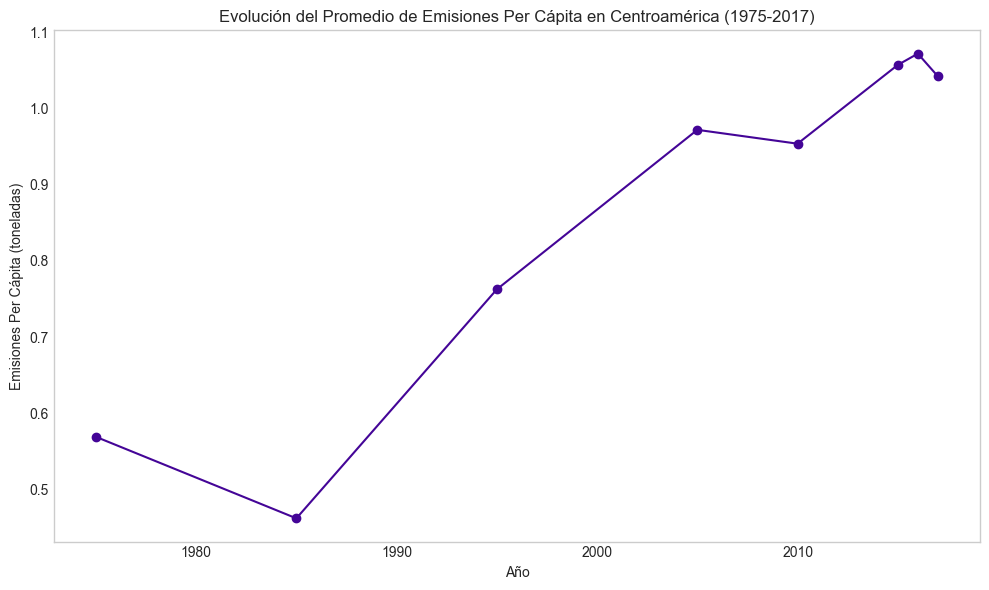

In [48]:
# 5.1 Construye aquí el gráfico de líneas
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
# ==========================================
# Gráfico 1: Evolución Per Cápita Centroamérica
# ==========================================

# Se configura el tamaño de la figura
plt.figure(figsize=(10, 6))

# Se crea el gráfico de líneas para el promedio per cápita en Centroamérica
plt.plot(
    reporte_promedio_centroamerica['anio'], 
    reporte_promedio_centroamerica['promedio_por_anio'], 
    marker='o', 
    linestyle='-', 
    color="#440597"
)

# Se asignan títulos y etiquetas de los ejes
plt.title('Evolución del Promedio de Emisiones Per Cápita en Centroamérica (1975-2017)')
plt.xlabel('Año')
plt.ylabel('Emisiones Per Cápita (toneladas)')
plt.grid(False)

# Se muestra el gráfico
plt.tight_layout()
plt.show()




### <mark>Lectura del gráfico 1</mark>
Elegí el gráfico de líneas porque es el estándar visual ideal para mostrar series de tiempo, y lo principal que permite ver es la tendencia histórica (subidas y bajadas) del promedio de emisiones a lo largo de las décadas en la región.


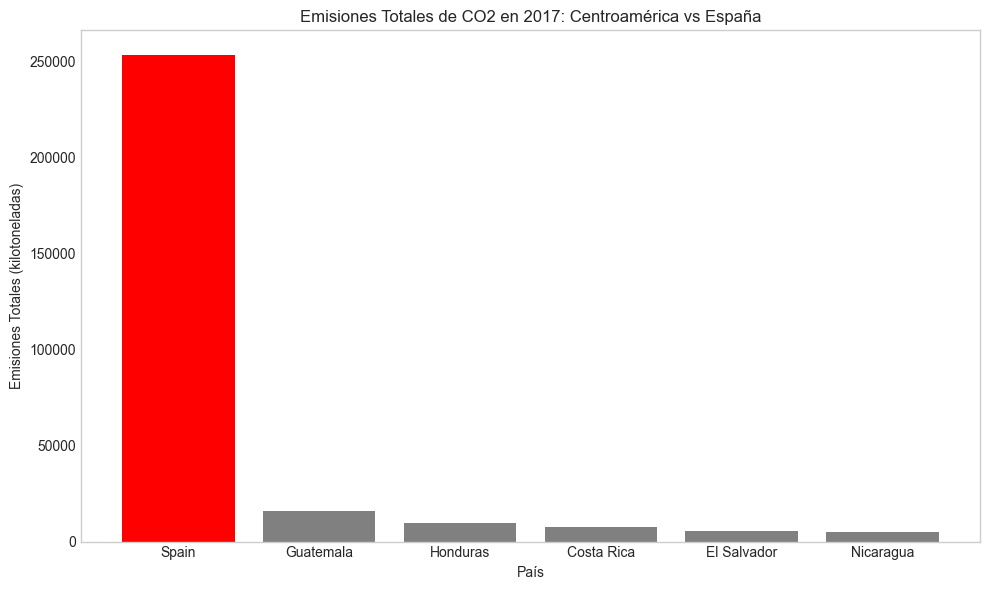

In [49]:
# 5.2 Construye aquí el gráfico de barras comparativo
# ==========================================
# Gráfico 2: Comparación Emisiones Totales 2017
# ==========================================

# Se configura el tamaño de la figura
plt.figure(figsize=(10, 6))

# Se define la lista de paises que se van a filtrar para comparar en el gráfico de barras
paises_grafico_2 = ['Costa Rica', 'Guatemala', 'Honduras', 'El Salvador', 'Nicaragua', 'Spain']

# Se filtra por el año y por los países de la lista
df_g2 = df_totales_es[(df_totales_es['anio'] == 2017) & (df_totales_es['pais'].isin(paises_grafico_2))]

# Se ordena de mayor a menor para que el gráfico de barras se vea más ordenado
df_g2 = df_g2.sort_values(by='valor', ascending=False)

# se crea el gráfico de barras
plt.bar(df_g2['pais'], df_g2['valor'], color=['red', 'gray', 'gray', 'gray', 'gray', 'gray'])

# Se asignan títulos y etiquetas de los ejes
plt.title('Emisiones Totales de CO2 en 2017: Centroamérica vs España')
plt.xlabel('País')
plt.ylabel('Emisiones Totales (kilotoneladas)')
plt.grid(False)

# Se muestra el gráfico
plt.tight_layout()
plt.show()


### <mark>Lectura del gráfico 2</mark>
Elegí el gráfico de barras porque es la mejor herramienta para comparar magnitudes absolutas entre diferentes categorías, y permite ver inmediatamente la enorme desproporción que existe entre las emisiones de un país europeo y los países centroamericanos en un mismo año.


### <mark>Interpretación de gráficos del Bloque 5</mark>
Al analizar ambos gráficos en conjunto, queda claro que es fundamental para no sacar conclusiones apresuradas. Si solo se visualiza el Gráfico 1, podría generarse una alarma por el crecimiento o los picos históricos en la tendencia per cápita de Centroamérica, pero al contrastarlo con el Gráfico 2, se dimensiona la realidad: toda la región centroamericana junta tiene un impacto ambiental absoluto diminuto si se le compara con el volumen industrial de una sola nación europea como España, demostrando que las métricas relativas (per cápita) deben siempre contextualizarse con la magnitud real (totales).


---
## Bloque 6 — Informe final crítico (20 pts)

### Objetivo
Cerrar el examen con una síntesis crítica basada en evidencia, no solo con una lista de resultados.

### Debes redactar un informe de 6 a 8 líneas que incluya obligatoriamente
- **2 hallazgos numéricos concretos**
- **1 limitación real del análisis**
- **1 comparación explícita entre emisiones totales y per cápita**
- **1 conclusión final** sobre el comportamiento de las emisiones en los países analizados
- **1 recomendación o advertencia final** basada en tus datos
- **coherencia clara** entre lo que exploraste, calculaste, graficaste y concluiste

### Regla importante
No describas solo resultados: explica qué significan.

### Nivel esperado
- **No logrado:** texto genérico sin cifras ni juicio analítico.
- **Inicial:** incluye alguna cifra, pero la conclusión es débil o desconectada.
- **Intermedio:** presenta hallazgos, limitación y conclusión coherente.
- **Logrado:** sintetiza, compara, limita e interpreta con evidencia concreta y criterio, y además propone una recomendación o advertencia defendible.


### <mark>Informe final crítico</mark>
Este análisis demuestra que la magnitud absoluta de la contaminación no refleja el verdadero impacto individual, pues mientras la potencia con el máximo global superó los 5 millones de kilotoneladas en emisiones totales, el promedio per cápita de Centroamérica apenas se mantuvo cerca de las 1.5 toneladas en 2005.

Al comparar métricas, es evidente que naciones europeas como España opacan a toda Centroamérica junta en emisiones totales debido a su enorme escala industrial, pero la métrica per cápita advierte que el estilo de vida en países menos poblados también genera una huella ecológica que no debe ignorarse. 

En conclusión, el comportamiento de las emisiones globales está sumamente polarizado: el volumen masivo recae sobre unas pocas potencias, pero la responsabilidad por habitante está mucho más distribuida. 

Una limitación real de este análisis es que los datos concluyen en 2017, dejándonos ciegos ante el impacto de las nuevas las nuevas tecnologías que se han incrementado estos últimos años,también las regulaciones climáticas de esta década y el efecto de la pandemia. Por ello, la advertencia final es clara: las políticas ambientales deben penalizar la producción masiva de la gran industria, pero los países pequeños no pueden usar sus bajas emisiones totales como excusa para evitar educar a su población en la reducción de su huella per cápita.


---
## Criterios de corrección visibles para el estudiante
- Se descontarán puntos si usas nombres distintos a los exigidos y eso dificulta la revisión.
- Se descontarán puntos si respondes con texto sin evidencia numérica.
- Se descontarán puntos si usas `pandas` para resolver lo que se pidió explícitamente con Python base.
- Se descontarán puntos si confundes emisiones totales con emisiones per cápita.
- Se descontarán puntos si generas gráficos sin título o sin ejes rotulados.
- Se reconocerá crédito parcial cuando el razonamiento sea correcto aunque el resultado final no sea exacto.
- Se valorará especialmente la coherencia entre exploración, análisis, gráficos e informe final.


## Checklist final de entrega
- [ ] Cargué y exploré el archivo correctamente.
- [ ] Expliqué qué representa una fila del dataset.
- [ ] Expliqué la diferencia entre emisiones totales y per cápita.
- [ ] Creé `df_trabajo`.
- [ ] Creé `df_totales_es` y `df_per_capita_es`.
- [ ] Creé `renombrar_columnas_es(df)` y `separar_por_tipo(df, tipo_emision)`.
- [ ] Escribí una `prediccion_inicial`.
- [ ] Creé `registros_totales`.
- [ ] Creé `resumen_pais(registros, pais)`.
- [ ] Construí `reporte_centroamerica_base`.
- [ ] Comparé mi predicción con la evidencia.
- [ ] Construí `reporte_total_centroamerica`.
- [ ] Construí `reporte_promedio_centroamerica`.
- [ ] Construí `conversiones_costa_rica`.
- [ ] Creé `comparar_paises(df, paises)`.
- [ ] Construí `comparacion_2017` y la usé como evidencia visible.
- [ ] Contrasté emisiones totales vs per cápita con un ejemplo concreto.
- [ ] Generé los 2 gráficos.
- [ ] Expliqué por qué cada gráfico era útil.
- [ ] Escribí el informe final crítico con recomendación o advertencia.
